# **1. Entendimiento del negocio**
En una clínica de ginecobstetricia, en la que se cuenta con la información de 2.126 histogramas a fetos. Se pide construir un modelo de clasificación que sea capaz de determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca. El modelo debería contar con un desempeño superior al 85% en accuracy y con la mejor matriz de confusión y f1 score posible.

# **2.Enfoque analítico**

Desarrollar un experimento de clasificación para determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca con un desempeño esperado mayor al 85%.

# **3. Recolección de datos**

In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

##Importación de los datos
data = pd.read_csv('datos_caso_2.csv')
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sb

# **5. Entendimiento de los datos**

- Análisis de Completitud: calidad de datos
- Análisis Univariado: entender cada variable
- Análisis Bivariado: relaciones simples entre variables
- Análisis Multivariado: relaciones complejas entre más de 2 variables

- Datos nulos
- Desbalance de y (fetal_health)

In [16]:
#Identificación de datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

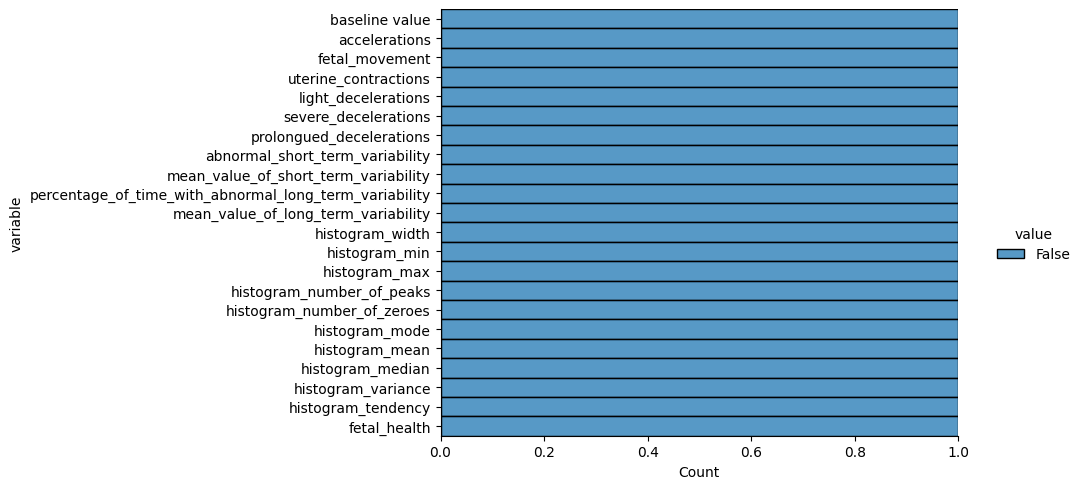

In [17]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', 
                                                hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

Según la información de la gráfica, ninguna variable tiene datos nulos

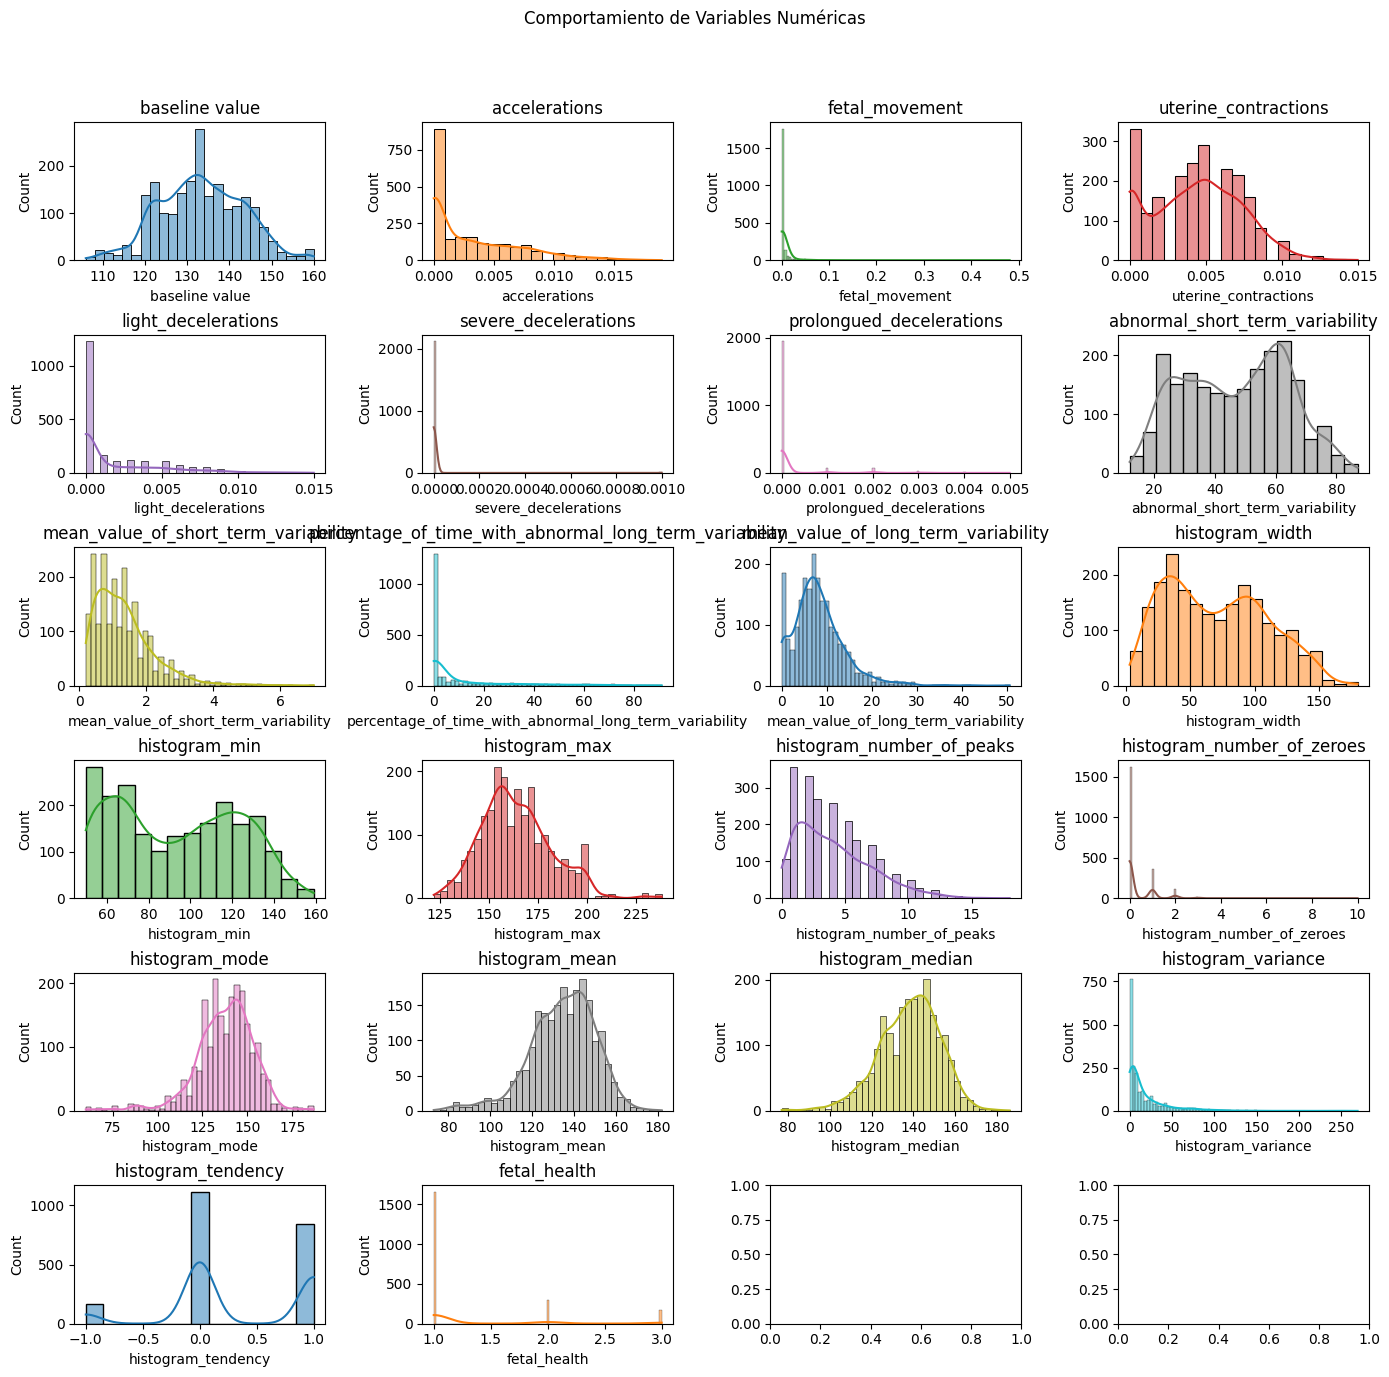

In [18]:
#Exploración univariada de los datos
##Para datos numéricos: histogramas de frecuencia
##Para datos categóricos: gráficos de torta

###HISTOGRAMAS DE FRECUENCIA
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, 
                kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

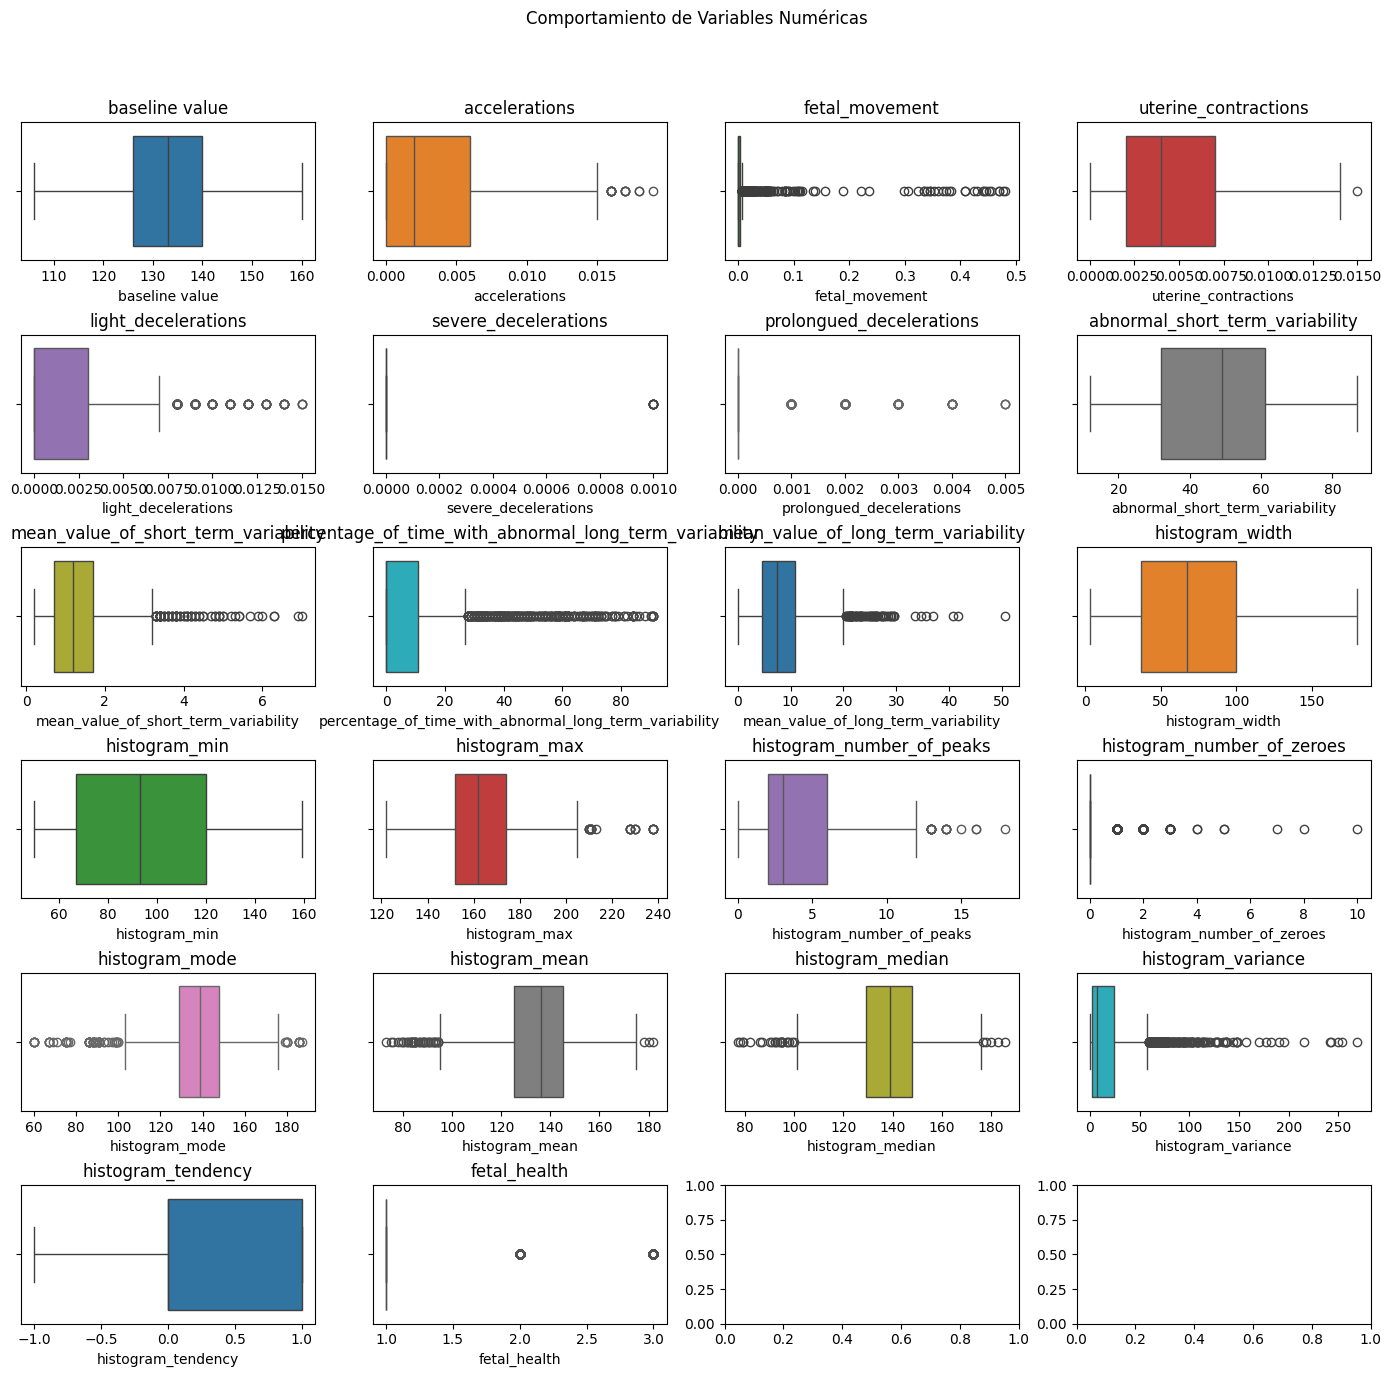

In [19]:
###CAJAS Y BIGOTES
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.boxplot(data = data, x = col, 
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

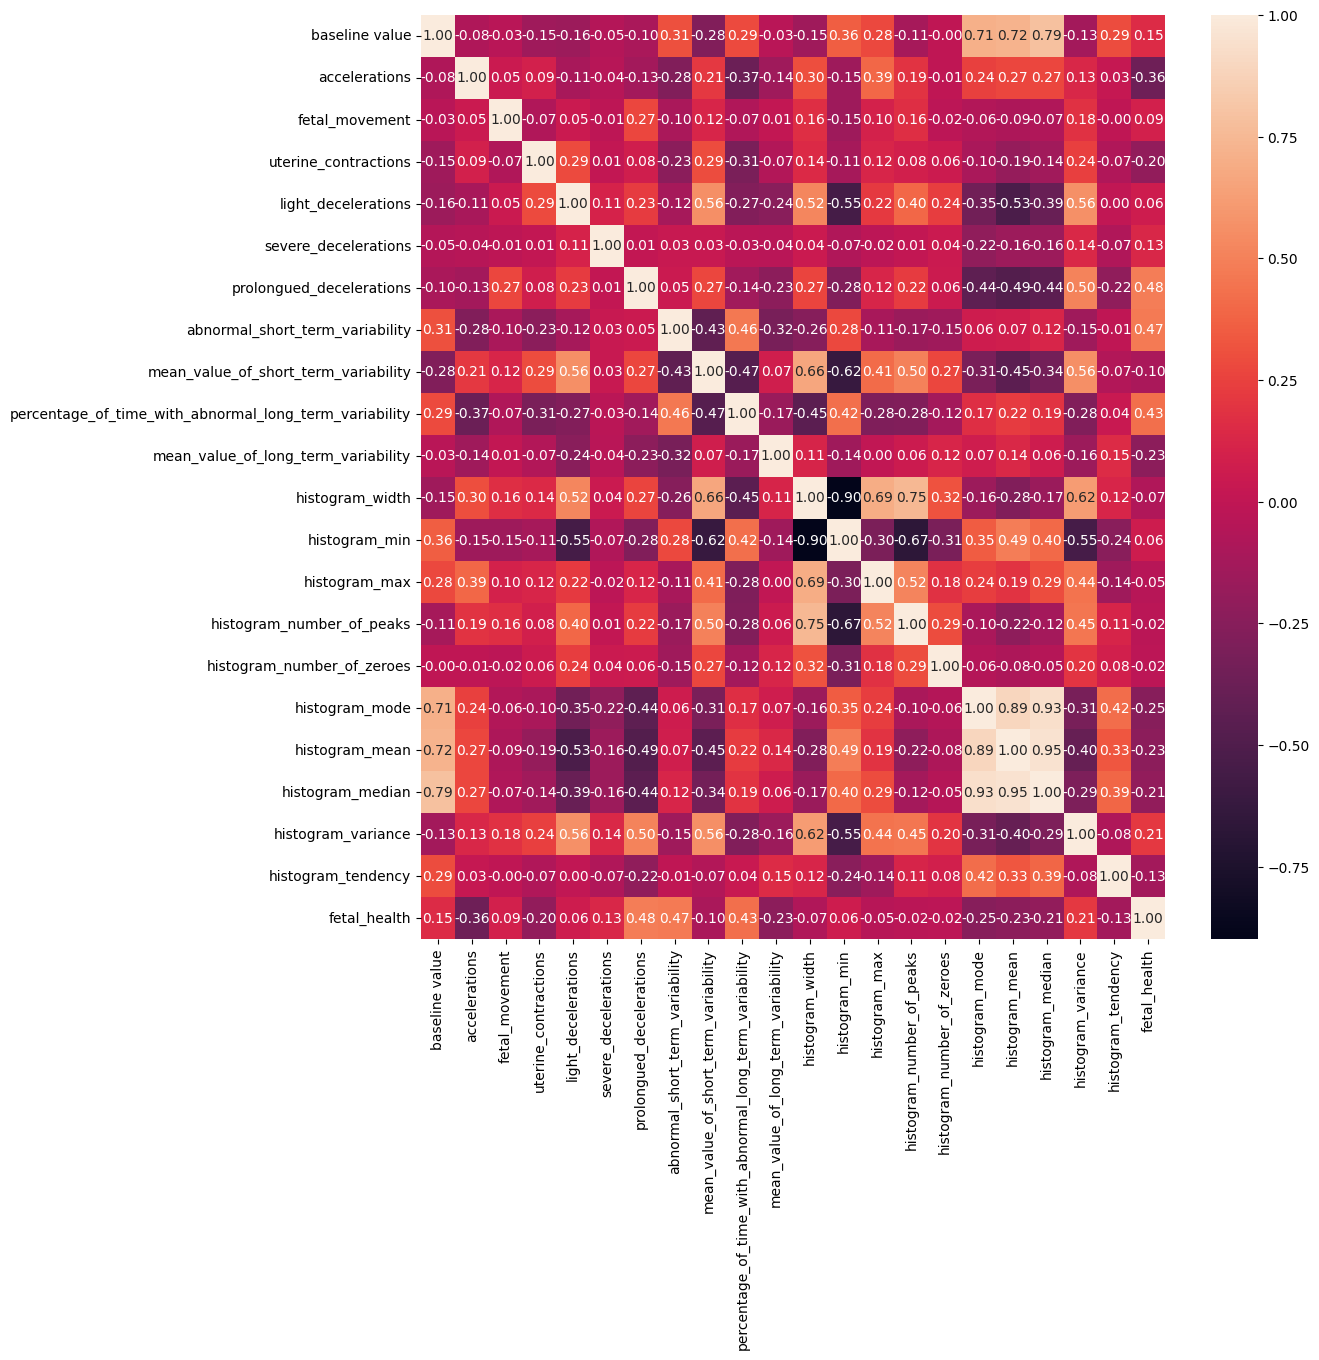

In [20]:
# Mapa de correlación
plt.figure(figsize=(12, 12))
sb.heatmap(data.corr(numeric_only=True), annot = True, fmt = '.2f')
plt.show()

In [21]:
# fetal_movements podría ser ignorada (muy concentrada y muy poca correlación)
# severe_decelerations candidata a eliminar (variable casi constante, poco aporte)

# eliminar histogram_mode y histogram_mean, me quedo con histogram_median (multicolinealidad)
# elimino histogram_min y posiblemente max, por muchas correlacion con width

# histogram_tendency y la Y fetal_health, tratar como categórica

# **6. Preparación de los datos**
- Ignorar las variables poco representativas
- Balancear la variable y (la variable que estoy supervisando, fetal_health, esta desbalanceada)
- Escalar variables numéricas y codificar variables categóricas
- Separar en conjuntos de entrenamiento y validación

In [22]:
# Pasar histogram_tendency a tipo categórico
data['histogram_tendency'] = data['histogram_tendency'].astype('str')

In [ ]:
# Se descarta fetal_movements y severe_decelerations por su baja variabilidad, variables muy sesgadas y con poca correlación con y.
data = data.drop(columns = ['fetal_movement', 'severe_decelerations'])
# prolongued_decelerations no se descarta, ya que aunque esta sesgada, tiene una alta correlacion con la variable objetivo

In [26]:
# Se descartan histogram_mode y histogram_mean, conservamos histogram_median (multicolinealidad)
data = data.drop(columns = ['histogram_mode', 'histogram_mean'])

In [27]:
#BALANCEO DE Y
data_high = data[data['fetal_health'] == 1]
data_medium = data[data['fetal_health'] == 2]
data_low = data[data['fetal_health'] == 3]
print(f'El tamaño de la clase 1 es: {data_high.shape}\nEl tamaño de la clase 2 es: {data_medium.shape}\nEl tamaño de la clase 3 es: {data_low.shape}')

# Se filtra por filas

El tamaño de la clase 1 es: (1655, 18)
El tamaño de la clase 2 es: (295, 18)
El tamaño de la clase 3 es: (176, 18)


In [28]:
# Se realiza oversampling de las clases minoritarias para igualar su tamaño
# al de la clase mayoritaria, permitiendo la repetición de registros 
data_medium_re = data_medium.sample(data_high.shape[0], replace = True)
data_low_re = data_low.sample(data_high.shape[0], replace = True)
data_balanced = pd.concat([data_high, data_medium_re, data_low_re])
data_balanced.reset_index(drop=True, inplace=True)
data_balanced.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 18 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          4965 non-null   float64
 1   accelerations                                           4965 non-null   float64
 2   uterine_contractions                                    4965 non-null   float64
 3   light_decelerations                                     4965 non-null   float64
 4   prolongued_decelerations                                4965 non-null   float64
 5   abnormal_short_term_variability                         4965 non-null   float64
 6   mean_value_of_short_term_variability                    4965 non-null   float64
 7   percentage_of_time_with_abnormal_long_term_variability  4965 non-null   float64
 8   mean_value_of_long_term_variability   

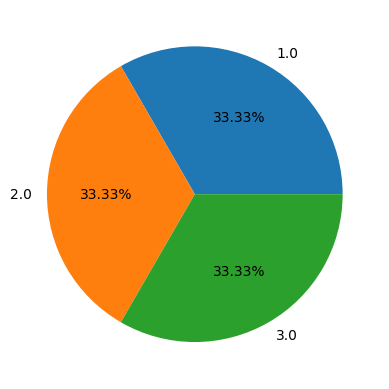

In [12]:
plt.pie(x = data_balanced.fetal_health.value_counts(), labels = data_balanced.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

In [30]:
# Separar X y Y
X = data_balanced.drop('fetal_health', axis = 1)
y = data_balanced[['fetal_health']]
print(f'El tamaño de X es: {X.shape} y el tamaño de y es: {y.shape}')

El tamaño de X es: (4965, 17) y el tamaño de y es: (4965, 1)


In [31]:
# Transformar X
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = X.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_col = X.select_dtypes(include = ['object']).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output = False))])
preprocessor = ColumnTransformer(transformers = [('num', num_transformer, num_col),
                                                 ('cat', cat_transformer, cat_col)],
                                                 remainder = 'passthrough')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [32]:
X_pre = preprocessor.fit_transform(X)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
X_pro = pd.DataFrame(X_pre, columns = labels)
X_pro.head(10)

,baseline value,accelerations,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_median,histogram_variance,histogram_tendency_-1.0,histogram_tendency_0.0,histogram_tendency_1.0
0,0.481481,0.315789,0.400000,0.200000,0.0,0.066667,0.279412,0.0,0.205128,0.717514,0.165138,0.655172,0.333333,0.1,0.577982,0.044610,0.0,1.0,0.0
1,0.500000,0.157895,0.533333,0.200000,0.0,0.053333,0.279412,0.0,0.264300,0.717514,0.165138,0.655172,0.277778,0.1,0.559633,0.048327,0.0,1.0,0.0
2,0.518519,0.157895,0.533333,0.200000,0.0,0.053333,0.323529,0.0,0.453649,0.644068,0.027523,0.413793,0.611111,0.0,0.550459,0.048327,0.0,0.0,1.0
3,0.481481,0.368421,0.533333,0.000000,0.0,0.053333,0.323529,0.0,0.392505,0.644068,0.027523,0.413793,0.500000,0.0,0.559633,0.040892,0.0,0.0,1.0
4,0.462963,0.263158,0.533333,0.200000,0.0,0.213333,0.176471,0.0,0.254438,0.355932,0.348624,0.275862,0.277778,0.0,0.550459,0.026022,0.0,0.0,1.0
5,0.462963,0.473684,0.400000,0.133333,0.0,0.213333,0.191176,0.0,0.106509,0.474576,0.192661,0.310345,0.111111,0.0,0.587156,0.037175,0.0,0.0,1.0
6,0.444444,0.315789,0.266667,0.333333,0.2,0.120000,0.308824,0.0,0.155819,0.587571,0.155963,0.448276,0.388889,0.0,0.532110,0.282528,0.0,1.0,0.0
7,0.444444,0.315789,0.266667,0.266667,0.2,0.093333,0.308824,0.0,0.171598,0.587571,0.155963,0.448276,0.166667,0.0,0.513761,0.159851,0.0,1.0,0.0
8,0.444444,0.315789,0.333333,0.333333,0.0,0.160000,0.279412,0.0,0.214990,0.689266,0.027523,0.482759,0.277778,0.0,0.559633,0.260223,0.0,0.0,1.0
9,0.444444,0.157895,0.400000,0.266667,0.2,0.146667,0.250000,0.0,0.173570,0.542373,0.082569,0.310345,0.333333,0.0,0.477064,0.133829,0.0,0.0,1.0


In [33]:
# Separar en conjuntos de entrenamiento y validación
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pro, y, train_size = 0.7, random_state = 123)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}\nEl tamaño del conjunto de validación es: {X_test.shape} {y_test.shape}')

El tamaño del conjunto de entrenamiento es: (3475, 19) (3475, 1)
El tamaño del conjunto de validación es: (1490, 19) (1490, 1)


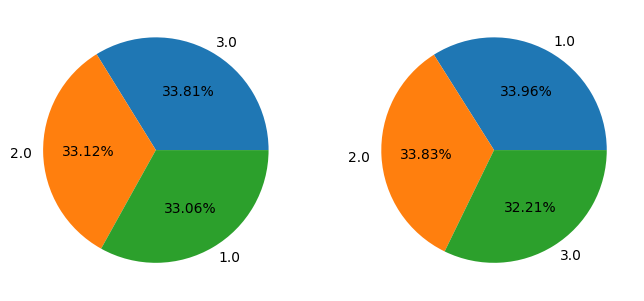

In [34]:
fig, ax = plt.subplots(1, 2, figsize = (8, 8))
ax[0].pie(x = y_train.fetal_health.value_counts(), labels = y_train.fetal_health.value_counts().index, autopct = '%0.2f%%')
ax[1].pie(x = y_test.fetal_health.value_counts(), labels = y_test.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

# **7. Modelado de Datos**

- Regresión Logística
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting
- Red Neuronal Artificial

In [ ]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
# Busqueda de hiperparámetros y validación cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Se define el modelo pero sin hiperparámetros optimos aún
# 'saga' es un tipo específico de solver basado en descenso por gradiente estocástico mejorado
model_1 = LogisticRegression(solver = 'saga', random_state = 123)
# Define todas las combinaciones de hiperparámetros a probar (24 modelos)
param_grid = {'penalty':['l1', 'l2', 'elasticnet'], 'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}
# Validación cruzada
# Stratified: Mantiene la proporción de clases en cada fold
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
# Se crea el sistema automático para probar muchos modelos y escoger el mejor
clf_1 = GridSearchCV(estimator = model_1, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
# Se ejecuta la combinación de hiperparámetros y cross validation
clf_1.fit(X_train, y_train)

In [ ]:
# Se construye una tabla con todas las combinaciones de hiperparámetros y su desempeño (F1 promedio)
# clf_1.cv_results_ es un diccionario que guarda todo lo que pasó en Grid Search
validation = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#K Vecinos Más Cercanos
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier()
# Hiperparámetros a probar (numero de vecinos y tipo de distancia)
param_grid = {'n_neighbors':[3, 5, 9, 7, 11, 15, 101], 'p':[1, 2]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_2 = GridSearchCV(estimator = model_2, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_2.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#Máquina de soporte vectorial
from sklearn.svm import SVC
model_3 = SVC(random_state=123)
# Hiperparámetros a probar (epsilon y kernel)
param_grid = {'C':[0.001, 0.01, 0.1, 10, 100], 'kernel':['poly','linear', 'rbf', 'sigmoid'], 'degree':[2, 3]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_3 = GridSearchCV(estimator = model_3, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_3.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#Árbol de Decisión

# Se crea el arbol de decisión puro, sin hiperparámetros optimos, para visualizar su estructura 
# y decidir cuales hiperparámetros probar en la busqueda de Grid Search
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state = 123)
model_tree.fit(X_train, y_train)
print(f'La profundidad del árbol es: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize = (15, 8))
plot = plot_tree(decision_tree = model_tree, feature_names = labels, filled=True, impurity=False, ax = ax)

In [ ]:
model_4 = DecisionTreeClassifier(random_state = 123)
# Hiperparámetros a probar (tipo de impureza, profundidad, numero de hojas y numero mínimo de muestras para dividir un nodo)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12], 
              'max_leaf_nodes':[None, 5, 10, 50, 100, 200], 
              'min_samples_split':[2, 4, 6]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_4 = GridSearchCV(estimator = model_4, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_4.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

MODELOS DE ENSAMBLE

In [ ]:
#ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
model_5 = ExtraTreesClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12], 
              'max_leaf_nodes':[None, 5, 10, 50, 100, 200], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_5 = GridSearchCV(estimator = model_5, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_5.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_5.cv_results_['params']),
                        pd.DataFrame(clf_5.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
model_6 = RandomForestClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12], 
              'max_leaf_nodes':[None, 5, 10, 50, 100, 200], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_6 = GridSearchCV(estimator = model_6, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_6.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_6.cv_results_['params']),
                        pd.DataFrame(clf_6.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#AdaptativeBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
model_7 = AdaBoostClassifier(random_state = 123)
param_grid = {'learning_rate':[0.01, 0.1, 1, 10, 100], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_7 = GridSearchCV(estimator = model_7, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_7.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_7.cv_results_['params']),
                        pd.DataFrame(clf_7.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_8 = GradientBoostingClassifier(random_state = 123)
param_grid = {'criterion':['friedman_mse', 'squared_error'], 'max_depth':[5,7,9,12],
              'max_leaf_nodes':[10,40,None], 'min_samples_split':[2,3], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_8 = RandomizedSearchCV(estimator = model_8, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 48)
clf_8.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_8.cv_results_['params']),
                        pd.DataFrame(clf_8.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

In [ ]:
# Red Neuronal Artificial - Multilayer Perceptron
from sklearn.neural_network import MLPClassifier
model_9 = MLPClassifier(random_state = 123)
param_grid = {'hidden_layer_sizes':[(10,), (20, 10, 5), (20, 10), (20,), (50, 40, 30, 20, 10)],
            'activation':['identity', 'logistic', 'tanh', 'relu'], 'solver':['adam', 'lbfgs', 'sdg'],
            'learning_rate_init':[0.01, 0.1, 1, 10, 100], 'max_iter':[50, 70, 100, 200]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_9 = RandomizedSearchCV(estimator = model_9, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 48)
clf_9.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_9.cv_results_['params']),
                        pd.DataFrame(clf_9.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

# **8. Validación del modelo**
- Calcular las predicciones del conjunto de validación
- Calcular las métricas de desempeño
- Elegir el mejor modelo

In [ ]:
model_rl = clf_1.best_estimator_
pred_rl = model_rl.predict(X_test)
model_knn = clf_2.best_estimator_
pred_knn = model_knn.predict(X_test)
model_svm = clf_3.best_estimator_
pred_svm = model_svm.predict(X_test)
model_dt = clf_4.best_estimator_
pred_dt = model_dt.predict(X_test)
model_et = clf_5.best_estimator_
pred_et = model_et.predict(X_test)
model_rf = clf_6.best_estimator_
pred_rf = model_rf.predict(X_test)
model_ab = clf_7.best_estimator_
pred_ab = model_ab.predict(X_test)
model_gb = clf_8.best_estimator_
pred_gb = model_gb.predict(X_test)
model_rna = clf_9.best_estimator_
pred_rna = model_rna.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def calculo_metricas(y_test, y_pred, modelo):
    print(f'Reporte de Clasificación - {modelo}')
    print(classification_report(y_test, y_pred))
    sb.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
    plt.show()

In [ ]:
# Regresion Logistica
calculo_metricas(y_test, pred_rl, 'Regresión Logística')

In [ ]:
# K Vecinos Más Cercanos
calculo_metricas(y_test, pred_knn, 'K Vecinos Más Cercanos')

In [ ]:
# Maquina de Soporte Vectorial
calculo_metricas(y_test, pred_svm, 'Maquina de Soporte Vectorial')

In [ ]:
# Decision Tree
calculo_metricas(y_test, pred_dt, 'Árbol de Decisión')

In [ ]:
# Extra Tree Classifier
calculo_metricas(y_test, pred_et, 'Extra Tree Classifier')

In [ ]:
# Random Forest Classifier
calculo_metricas(y_test, pred_rf, 'Random Forest Classifier')

In [ ]:
# Adaptative Boosting Classifier
calculo_metricas(y_test, pred_ab, 'Adaptative Boosting Classifier')

In [ ]:
# Gradient Boosting Classifier
calculo_metricas(y_test, pred_gb, 'Gradient Boosting Classifier')

In [ ]:
# Perceptron multicapa
calculo_metricas(y_test, pred_rna, 'Perceptron Multicapa')

# **9. Despliegue del Modelo**
- Construir el Pipeline
- Almacenar el Pipeline en un esquema externo

In [ ]:
data = pd.read_csv('data_clf.csv')
target = 'Addiction'
X = data.drop(columns=target)
y = data[[target]]

In [ ]:
# Selección de características
ignored = ['ID', 'Name', 'Location']
all_num = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
all_cat = X.select_dtypes(include=['object']).columns.to_list()
num_features = [col for col in all_num if col not in ignored]
cat_features = [col for col in all_cat if col not in ignored]

In [ ]:
# Imputación de características
from sklearn.impute import SimpleImputer, KNNImputer
num_pipe = Pipeline(steps=[('num_imputer', KNNImputer()), ('scaler', MinMaxScaler())])
num_pipe

In [ ]:
cat_pipe = Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(sparse_output=False))])
cat_pipe

In [ ]:
# Se usa el modelo que mejor desempeño tuvo en el f1_score, que no este sobreajustado, de menor complejidad computacional
# y que tenga una matriz de confusión balanceada.
model_gb

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', num_pipe, num_features),
                                               ('cat', cat_pipe, cat_features)], remainder='drop')
model = GradientBoostingClassifier(max_depth=9, n_estimators=400, random_state=123)
pipe_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
pipe_model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)
pipe_model.fit(X_train, y_train)

In [ ]:
import joblib
joblib.dump(pipe_model, 'addiction_model.pkl')


In [ ]:
model = joblib.load('addiction_model.pkl')
model

In [ ]:
model.predict(X_test)